## CS 5864: Part 1 (YOLO) Starter Code

In [1]:
import os
import random

import cv2
import numpy as np

import torch
from torch.utils.data import DataLoader
from torchvision import models

from src.resnet_yolo import resnet50
from yolo_loss import YoloLoss
from src.dataset import VocDetectorDataset
from src.eval_voc import evaluate
from src.predict import predict_image
from src.config import VOC_CLASSES, COLORS

import matplotlib.pyplot as plt
import collections

%matplotlib inline
%load_ext autoreload
%autoreload 2

## Initialization

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu") # You need to use a GPU for this assignment - though development on CPU is OK

In [3]:
# YOLO network hyperparameters
B = 2  # number of bounding box predictions per cell
S = 14  # width/height of network output grid (larger than 7x7 from paper since we use a different network)

In this project, you'll create an object detection system based on a modified implementation of YOLO using established frameworks and libraries. The implementation leverages a pre-existing model and uses PyTorch's [`torchvision.models`](https://pytorch.org/docs/stable/torchvision/models.html) package. Specifically, we adopt the ResNet50 architecture as the backbone. This choice deviates from the original YOLO paper's architecture and yields an output grid size of 14x14, unlike the traditional 7x7 grid.

Models are often pretrained on the ImageNet dataset due to its extensive size (exceeding 1 million images) and widespread usage. The pretrained model's primary advantage is its well-tuned weight initialization, significantly aiding the efficiency and speed of learning for our detection network

In [4]:
load_network_path = None #'checkpoints/best_detector.pth' 
pretrained = True

# use to load a previously trained network
if load_network_path is not None:
    print('Loading saved network from {}'.format(load_network_path))
    net = resnet50().to(device)
    net.load_state_dict(torch.load(load_network_path))
else:
    print('Load pre-trained model')
    net = resnet50(pretrained=pretrained).to(device)

Load pre-trained model


/home/grads/xiaoyanzang24/miniconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/grads/xiaoyanzang24/miniconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [5]:
learning_rate = 0.001
num_epochs = 50
batch_size = 24

# Yolo loss component coefficients (as given in the paper)
lambda_coord = 5
lambda_noobj = 0.5

## Data Processing

Given the relatively modest size of the Pascal dataset (5000 images in total across train and validation splits), we've opted to amalgamate these splits for training our detector. While it's generally discouraged to merge train and validation sets, in this particular scenario for the homework, we're making an exception to attain reasonably accurate detection results with a dataset that's comparatively smaller for object detection purposes.

The training dataset loader incorporates an array of diverse data augmentation methods, including random shifts, scaling, cropping, and flips. Notably, data augmentation for detection datasets involves a higher level of complexity as the bounding box annotations need to remain consistent across various transformations!

As the output of our trained detector network is an SxSx(B*5+C) structure, an encoder is employed to convert the original bounding box coordinates into relative grid bounding box coordinates, aligning with the anticipated output format. Additionally, a decoder is utilized to facilitate the reverse transformation, converting grid-based coordinates back to image-based bounding boxes.

In [6]:
file_root_train = 'data/VOCdevkit_2007/VOC2007/JPEGImages/'
annotation_file_train = 'data/voc2007.txt'

train_dataset = VocDetectorDataset(root_img_dir=file_root_train,dataset_file=annotation_file_train,train=True, S=S)
train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True,num_workers=2)
print('Loaded %d train images' % len(train_dataset))

Initializing dataset
Loaded 5011 train images


In [7]:
file_root_test = 'data/VOCdevkit_2007/VOC2007test/JPEGImages/'
annotation_file_test = 'data/voc2007test.txt'

test_dataset = VocDetectorDataset(root_img_dir=file_root_test,dataset_file=annotation_file_test,train=False, S=S)
test_loader = DataLoader(test_dataset,batch_size=batch_size,shuffle=False,num_workers=2)
print('Loaded %d test images' % len(test_dataset))

Initializing dataset
Loaded 4950 test images


In [8]:
data = train_dataset[0]

## Training tools

In [22]:
criterion = YoloLoss(S, B, lambda_coord, lambda_noobj)
optimizer = torch.optim.SGD(net.parameters(), lr=learning_rate, momentum=0.9, weight_decay=5e-4)

## Train detector

In [23]:
best_test_loss = np.inf
learning_rate = 1e-3
for epoch in range(num_epochs):
    net.train()
    
    # Update learning rate late in training
    if epoch == 30 or epoch == 40:
        learning_rate /= 10.0

    for param_group in optimizer.param_groups:
        param_group['lr'] = learning_rate
    
    print('\n\nStarting epoch %d / %d' % (epoch + 1, num_epochs))
    print('Learning Rate for this epoch: {}'.format(learning_rate))
    
    total_loss = collections.defaultdict(int)
    
    for i, data in enumerate(train_loader):
        data = (item.to(device) for item in data)
        images, target_boxes, target_cls, has_object_map = data
        
        # images = images.to(device)
        # target_boxes = target_boxes.to(device)
        # target_cls = target_cls.to(device)
        # has_object_map = has_object_map.to(device)
        
        pred = net(images)
        loss_dict = criterion(pred, target_boxes, target_cls, has_object_map)
        for key in loss_dict:
            total_loss[key] += loss_dict[key].item()
        
        optimizer.zero_grad()
        loss_dict['total_loss'].backward()
        optimizer.step()
        
        if (i+1) % 50 == 0:
            outstring = 'Epoch [%d/%d], Iter [%d/%d], Loss: ' % ((epoch+1, num_epochs, i+1, len(train_loader)))
            outstring += ', '.join( "%s=%.3f" % (key[:-5], val / (i+1)) for key, val in total_loss.items() )
            print(outstring)
    
    # evaluate the network on the test data
    if (epoch + 1) % 5 == 0:
        test_aps = evaluate(net, test_dataset_file=annotation_file_test, img_root=file_root_test)
        print(epoch, test_aps)
    with torch.no_grad():
        test_loss = 0.0
        net.eval()
        for i, data in enumerate(test_loader):
            data = (item.to(device) for item in data)
            images, target_boxes, target_cls, has_object_map = data
            
            pred = net(images)
            loss_dict = criterion(pred, target_boxes, target_cls, has_object_map)
            test_loss += loss_dict['total_loss'].item()
        test_loss /= len(test_loader)
    
    if best_test_loss > test_loss:
        best_test_loss = test_loss
        print('Updating best test loss: %.5f' % best_test_loss)
        torch.save(net.state_dict(),'checkpoints/best_detector.pth')
    
    if (epoch+1) in [5, 10, 20, 30, 40]:
        torch.save(net.state_dict(),'checkpoints/detector_epoch_%d.pth' % (epoch+1))

    torch.save(net.state_dict(),'checkpoints/detector.pth')
    




Starting epoch 1 / 50
Learning Rate for this epoch: 0.001
Epoch [1/50], Iter [50/209], Loss: total=167.261, reg=66.364, containing_obj=2.961, no_obj=0.151, cls=97.785
Epoch [1/50], Iter [100/209], Loss: total=137.670, reg=61.422, containing_obj=2.223, no_obj=0.115, cls=73.910
Epoch [1/50], Iter [150/209], Loss: total=125.735, reg=59.188, containing_obj=1.919, no_obj=0.094, cls=64.534
Epoch [1/50], Iter [200/209], Loss: total=119.992, reg=58.073, containing_obj=1.763, no_obj=0.082, cls=60.074
Updating best test loss: 104.99307


Starting epoch 2 / 50
Learning Rate for this epoch: 0.001
Epoch [2/50], Iter [50/209], Loss: total=101.605, reg=55.065, containing_obj=1.259, no_obj=0.038, cls=45.242
Epoch [2/50], Iter [100/209], Loss: total=100.559, reg=54.503, containing_obj=1.231, no_obj=0.035, cls=44.790
Epoch [2/50], Iter [150/209], Loss: total=99.049, reg=53.785, containing_obj=1.213, no_obj=0.034, cls=44.017
Epoch [2/50], Iter [200/209], Loss: total=98.070, reg=53.246, containing_obj=1

100%|██████████| 4950/4950 [16:37<00:00,  4.96it/s]


---class aeroplane ap 0.013069404649074134---
---class bicycle ap 0.0005948691694991871---
---class bird ap 2.265885842405374e-06---
---class boat ap 2.525664534199083e-05---
---class bottle ap 0.0---
---class bus ap 0.0---
---class car ap 0.02895380066222859---
---class cat ap 0.005085031500848317---
---class chair ap 0.001328065277879002---
---class cow ap 0.0---
---class diningtable ap 8.584570754147587e-06---
---class dog ap 0.0004668644968016006---
---class horse ap 0.0010102760955700094---
---class motorbike ap 0.00014577195853791598---
---class person ap 0.07307596709369032---
---class pottedplant ap 1.2604556226363093e-05---
---class sheep ap 2.8514079254395942e-05---
---class sofa ap 1.222840707878029e-06---
---class train ap 0.0008865248226950354---
---class tvmonitor ap 9.887470219526769e-05---
---map 0.006239694950357329---
4 [np.float64(0.013069404649074134), np.float64(0.0005948691694991871), np.float64(2.265885842405374e-06), np.float64(2.525664534199083e-05), np.float64

100%|██████████| 4950/4950 [15:10<00:00,  5.44it/s]


---class aeroplane ap 0.15040831041911135---
---class bicycle ap 0.018426594728000557---
---class bird ap 0.0008895944970400646---
---class boat ap 0.002780877647572612---
---class bottle ap 9.277873305034002e-06---
---class bus ap 0.00013808340237503452---
---class car ap 0.08077457200170049---
---class cat ap 0.0024730541195360197---
---class chair ap 0.003800481905918804---
---class cow ap 1.3892747985551542e-05---
---class diningtable ap 0.013943630208236546---
---class dog ap 0.029754942504630434---
---class horse ap 0.08419341481218089---
---class motorbike ap 0.04379181780998933---
---class person ap 0.09275835184425874---
---class pottedplant ap 0.00025030789941219247---
---class sheep ap 0.0005742734067092827---
---class sofa ap 3.040558523427677e-05---
---class train ap 0.0628639368587551---
---class tvmonitor ap 0.02154162900872844---
---map 0.030470872464034036---
9 [np.float64(0.15040831041911135), np.float64(0.018426594728000557), np.float64(0.0008895944970400646), np.flo

...

---class aeroplane ap 0.2197206616391638---
---class bicycle ap 0.19707567535091575---
---class bird ap 0.03559485486969974---
---class boat ap 0.0639652775230137---
---class bottle ap 0.0013854400619566895---
---class bus ap 0.2730940000402337---
---class car ap 0.3324076509526214---
---class cat ap 0.1359405686780767---
---class chair ap 0.042171162579007895---
---class cow ap 0.05527997410223365---
---class diningtable ap 0.14529626594585887---
---class dog ap 0.061989543549885555---
---class horse ap 0.3285344346406539---
---class motorbike ap 0.33202804523937285---
---class person ap 0.2675526836040341---
---class pottedplant ap 0.021801301694850946---
---class sheep ap 0.06222181884079975---
---class sofa ap 0.1082675190168672---
---class train ap 0.3652086560193687---
---class tvmonitor ap 0.11807521817101908---
---map 0.1583805376259817---
39 [np.float64(0.2197206616391638), np.float64(0.19707567535091575), np.float64(0.03559485486969974), np.float64(0.0639652775230137), np.flo

100%|██████████| 4950/4950 [16:18<00:00,  5.06it/s]


---class aeroplane ap 0.22106678878032843---
---class bicycle ap 0.19409469522611866---
---class bird ap 0.045893441292439933---
---class boat ap 0.06503557110234846---
---class bottle ap 0.0017581081076581343---
---class bus ap 0.2760969910875392---
---class car ap 0.3328871620551356---
---class cat ap 0.14720429544864028---
---class chair ap 0.047176250600544194---
---class cow ap 0.06584194933362611---
---class diningtable ap 0.14067462811693976---
---class dog ap 0.06698369398587614---
---class horse ap 0.33484117149815945---
---class motorbike ap 0.3157321261027661---
---class person ap 0.273873303703303---
---class pottedplant ap 0.023387639204148263---
---class sheep ap 0.05788056386967646---
---class sofa ap 0.11091549340356639---
---class train ap 0.3592705628258596---
---class tvmonitor ap 0.12239660914279271---
---map 0.16015055224437336---
44 [np.float64(0.22106678878032843), np.float64(0.19409469522611866), np.float64(0.045893441292439933), np.float64(0.06503557110234846),

100%|██████████| 4950/4950 [19:29<00:00,  4.23it/s]


---class aeroplane ap 0.21743572846311335---
---class bicycle ap 0.2037583182869279---
---class bird ap 0.04414826341939937---
---class boat ap 0.06368771800817366---
---class bottle ap 0.0015344838050749352---
---class bus ap 0.2842116914139473---
---class car ap 0.3346150993269548---
---class cat ap 0.139126327468735---
---class chair ap 0.047042880322415534---
---class cow ap 0.06779894571119595---
---class diningtable ap 0.13083955040761885---
---class dog ap 0.06668561973547682---
---class horse ap 0.33974155805447287---
---class motorbike ap 0.3342970660690381---
---class person ap 0.27652632819696843---
---class pottedplant ap 0.02190950806634799---
---class sheep ap 0.055369824905454904---
---class sofa ap 0.10802222127232432---
---class train ap 0.349069684136467---
---class tvmonitor ap 0.11760154892408303---
---map 0.16017111829970954---
49 [np.float64(0.21743572846311335), np.float64(0.2037583182869279), np.float64(0.04414826341939937), np.float64(0.06368771800817366), np.f

# View some predictions

predicting...


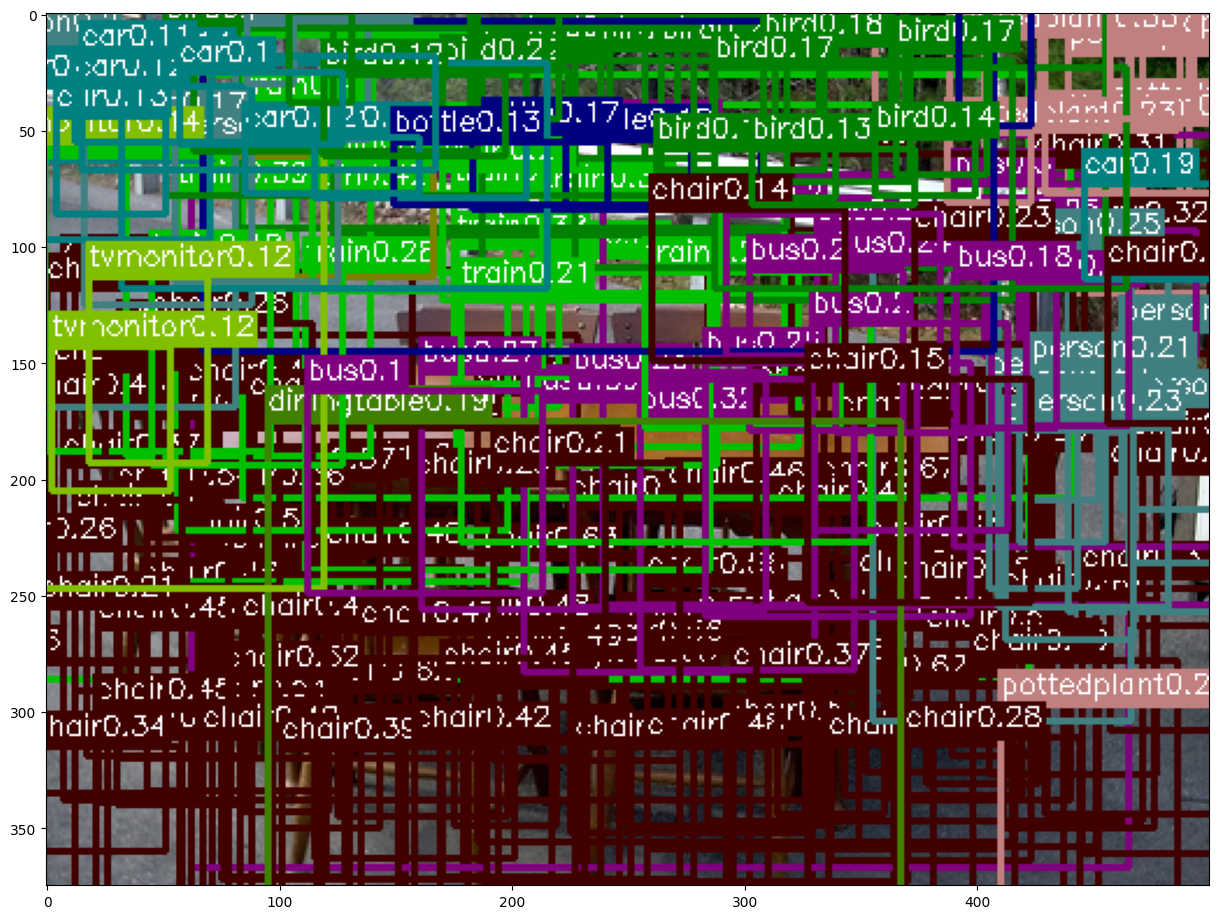

In [24]:
net.eval() # Remember to always put your model into eval mode when evaluating!

# select random image from test set
image_name = random.choice(test_dataset.fnames)
image = cv2.imread(os.path.join(file_root_test, image_name))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print('predicting...')
result = predict_image(net, image_name, root_img_directory=file_root_test)
for left_up, right_bottom, class_name, _, prob in result:
    color = COLORS[VOC_CLASSES.index(class_name)]
    cv2.rectangle(image, left_up, right_bottom, color, 2)
    label = class_name + str(round(prob, 2))
    text_size, baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.4, 1)
    p1 = (left_up[0], left_up[1] - text_size[1])
    cv2.rectangle(image, (p1[0] - 2 // 2, p1[1] - 2 - baseline), (p1[0] + text_size[0], p1[1] + text_size[1]),
                  color, -1)
    cv2.putText(image, label, (p1[0], p1[1] + baseline), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1, 8)

plt.figure(figsize = (15,15))
plt.imshow(image)


## Evaluate on Test

To evaluate detection results we use mAP (mean of average precision over each class)

In [12]:
test_aps = evaluate(net, test_dataset_file=annotation_file_test, img_root=file_root_test)

---Evaluate model on test samples---


100%|██████████| 4950/4950 [13:24<00:00,  6.15it/s]


---class aeroplane ap 0.0001663440468381016---
---class bicycle ap 0.0---
---class bird ap 0.0--- (no predictions for this class)
---class boat ap 0.0---
---class bottle ap 0.0---
---class bus ap 0.0---
---class car ap 0.0---
---class cat ap 0.0---
---class chair ap 0.0--- (no predictions for this class)
---class cow ap 0.0---
---class diningtable ap 0.0--- (no predictions for this class)
---class dog ap 0.0--- (no predictions for this class)
---class horse ap 0.0--- (no predictions for this class)
---class motorbike ap 0.0--- (no predictions for this class)
---class person ap 0.0--- (no predictions for this class)
---class pottedplant ap 0.0--- (no predictions for this class)
---class sheep ap 0.0--- (no predictions for this class)
---class sofa ap 0.0--- (no predictions for this class)
---class train ap 0.0--- (no predictions for this class)
---class tvmonitor ap 0.0--- (no predictions for this class)
---map 8.31720234190508e-06---


### Get intermediate mAP values

In [10]:

network_paths = ['checkpoints/detector_epoch_%d.pth' % epoch for epoch in [5, 10, 20, 30, 40]]+['checkpoints/detector.pth']
for load_network_path in network_paths:
    print('Loading saved network from {}'.format(load_network_path))
    net_loaded =  resnet50().to(device)
    net_loaded.load_state_dict(torch.load(load_network_path))
    evaluate(net_loaded, test_dataset_file=annotation_file_test, img_root=file_root_test)

Loading saved network from checkpoints/detector_epoch_5.pth
---Evaluate model on test samples---


100%|██████████| 4950/4950 [18:48<00:00,  4.39it/s]


---class aeroplane ap 0.013069404649074134---
---class bicycle ap 0.0005948691694991871---
---class bird ap 2.265885842405374e-06---
---class boat ap 2.525664534199083e-05---
---class bottle ap 0.0---
---class bus ap 0.0---
---class car ap 0.02895380066222859---
---class cat ap 0.005085031500848317---
---class chair ap 0.001328065277879002---
---class cow ap 0.0---
---class diningtable ap 8.584570754147587e-06---
---class dog ap 0.0004668644968016006---
---class horse ap 0.0010102760955700094---
---class motorbike ap 0.00014577195853791598---
---class person ap 0.07307596709369032---
---class pottedplant ap 1.2604556226363093e-05---
---class sheep ap 2.8514079254395942e-05---
---class sofa ap 1.222840707878029e-06---
---class train ap 0.0008865248226950354---
---class tvmonitor ap 9.887470219526769e-05---
---map 0.006239694950357329---
Loading saved network from checkpoints/detector_epoch_10.pth
---Evaluate model on test samples---


100%|██████████| 4950/4950 [15:28<00:00,  5.33it/s]


---class aeroplane ap 0.15040831041911135---
---class bicycle ap 0.018426594728000557---
---class bird ap 0.0008895944970400646---
---class boat ap 0.002780877647572612---
---class bottle ap 9.277873305034002e-06---
---class bus ap 0.00013808340237503452---
---class car ap 0.08077457200170049---
---class cat ap 0.0024730541195360197---
---class chair ap 0.003800481905918804---
---class cow ap 1.3892747985551542e-05---
---class diningtable ap 0.013943630208236546---
---class dog ap 0.029754942504630434---
---class horse ap 0.08419341481218089---
---class motorbike ap 0.04379181780998933---
---class person ap 0.09275835184425874---
---class pottedplant ap 0.00025030789941219247---
---class sheep ap 0.0005742734067092827---
---class sofa ap 3.040558523427677e-05---
---class train ap 0.0628639368587551---
---class tvmonitor ap 0.02154162900872844---
---map 0.030470872464034036---
Loading saved network from checkpoints/detector_epoch_20.pth
---Evaluate model on test samples---


...

---class aeroplane ap 0.16930464454350078---
---class bicycle ap 0.1258643761929228---
---class bird ap 0.017066582803705682---
---class boat ap 0.05160257769288734---
---class bottle ap 0.00011691470351017783---
---class bus ap 0.17930594644978226---
---class car ap 0.23978919875168692---
---class cat ap 0.11383812106303422---
---class chair ap 0.010422734308523952---
---class cow ap 0.024239534344980003---
---class diningtable ap 0.029429147379635777---
---class dog ap 0.0622357864321409---
---class horse ap 0.31003695766354894---
---class motorbike ap 0.08853943429111095---
---class person ap 0.2018100774347584---
---class pottedplant ap 0.014397833444626695---
---class sheep ap 0.0012430443734928027---
---class sofa ap 0.03741042944919932---
---class train ap 0.19014778775696184---
---class tvmonitor ap 0.07450058797397395---
---map 0.09706508585269917---
Loading saved network from checkpoints/detector_epoch_40.pth
---Evaluate model on test samples---


100%|██████████| 4950/4950 [16:16<00:00,  5.07it/s]


---class aeroplane ap 0.2197206616391638---
---class bicycle ap 0.19707567535091575---
---class bird ap 0.03559485486969974---
---class boat ap 0.0639652775230137---
---class bottle ap 0.0013854400619566895---
---class bus ap 0.2730940000402337---
---class car ap 0.3324076509526214---
---class cat ap 0.1359405686780767---
---class chair ap 0.042171162579007895---
---class cow ap 0.05527997410223365---
---class diningtable ap 0.14529626594585887---
---class dog ap 0.061989543549885555---
---class horse ap 0.3285344346406539---
---class motorbike ap 0.33202804523937285---
---class person ap 0.2675526836040341---
---class pottedplant ap 0.021801301694850946---
---class sheep ap 0.06222181884079975---
---class sofa ap 0.1082675190168672---
---class train ap 0.3652086560193687---
---class tvmonitor ap 0.11807521817101908---
---map 0.1583805376259817---
Loading saved network from checkpoints/detector.pth
---Evaluate model on test samples---


100%|██████████| 4950/4950 [16:50<00:00,  4.90it/s]


---class aeroplane ap 0.21743572846311335---
---class bicycle ap 0.2037583182869279---
---class bird ap 0.04414826341939937---
---class boat ap 0.06368771800817366---
---class bottle ap 0.0015344838050749352---
---class bus ap 0.2842116914139473---
---class car ap 0.3346150993269548---
---class cat ap 0.139126327468735---
---class chair ap 0.047042880322415534---
---class cow ap 0.06779894571119595---
---class diningtable ap 0.13083955040761885---
---class dog ap 0.06668561973547682---
---class horse ap 0.33974155805447287---
---class motorbike ap 0.3342970660690381---
---class person ap 0.27652632819696843---
---class pottedplant ap 0.02190950806634799---
---class sheep ap 0.055369824905454904---
---class sofa ap 0.10802222127232432---
---class train ap 0.349069684136467---
---class tvmonitor ap 0.11760154892408303---
---map 0.16017111829970954---


### Action Item:

Write code to print the mAP over all the classes, as well as the average precision for each class.
Report the mAP of your best model and the average precision over all classes. 
In addition, show the precision recall curves for all classes. You can compute this easily with [Scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_curve.html).
Take a look into the eval_voc.py function to help with this.

---Evaluate model on test samples---


100%|██████████| 4950/4950 [16:00<00:00,  5.15it/s]


---class aeroplane ap 0.22106678878032843---
---class bicycle ap 0.19409469522611866---
---class bird ap 0.045893441292439933---
---class boat ap 0.06503557110234846---
---class bottle ap 0.0017581081076581343---
---class bus ap 0.2760969910875392---
---class car ap 0.3328871620551356---
---class cat ap 0.14720429544864028---
---class chair ap 0.047176250600544194---
---class cow ap 0.06584194933362611---
---class diningtable ap 0.14067462811693976---
---class dog ap 0.06698369398587614---
---class horse ap 0.33484117149815945---
---class motorbike ap 0.3157321261027661---
---class person ap 0.273873303703303---
---class pottedplant ap 0.023387639204148263---
---class sheep ap 0.05788056386967646---
---class sofa ap 0.11091549340356639---
---class train ap 0.3592705628258596---
---class tvmonitor ap 0.12239660914279271---
---map 0.16015055224437336---


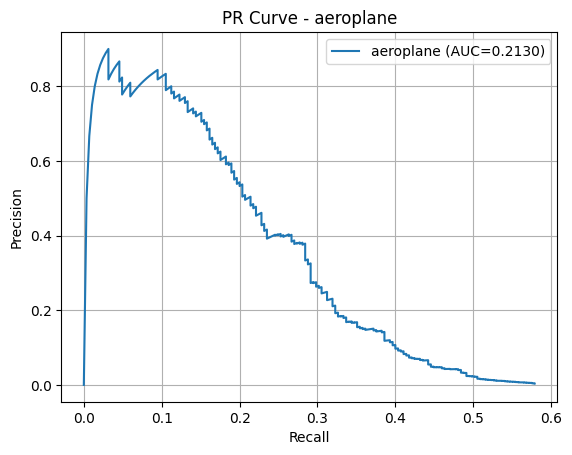

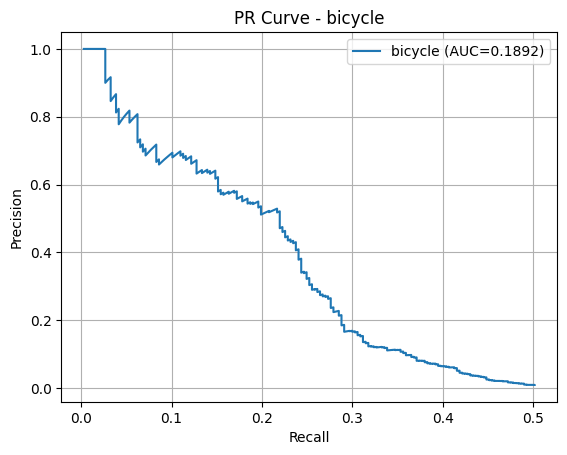

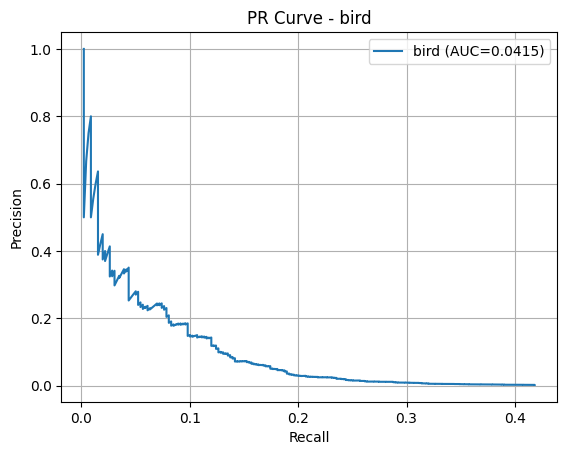

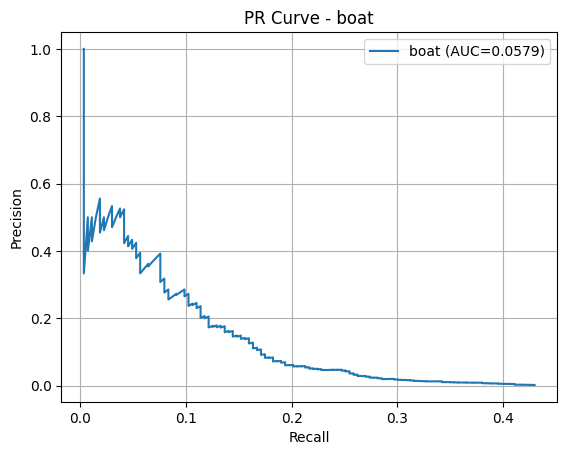

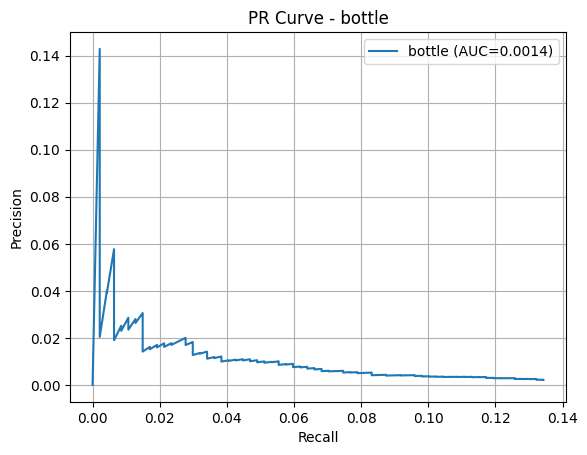

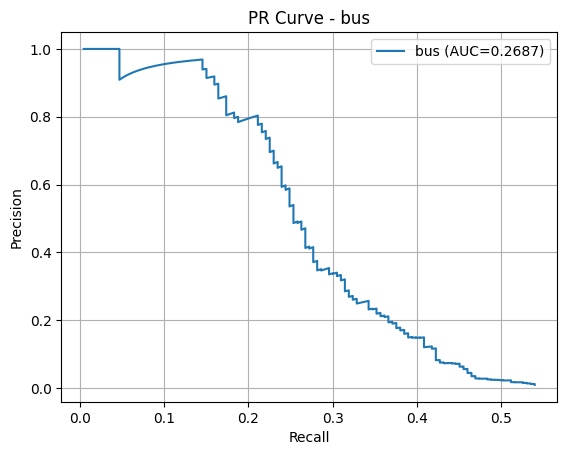

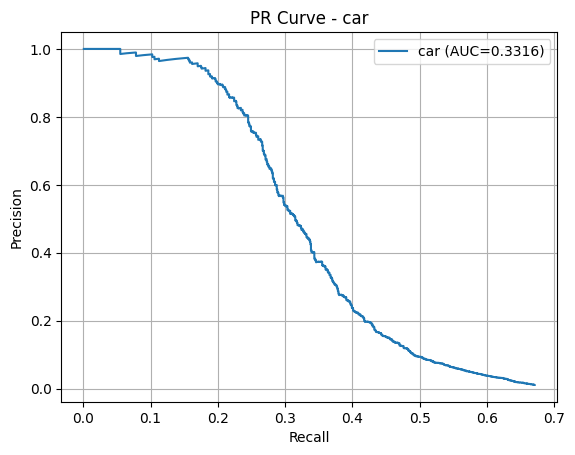

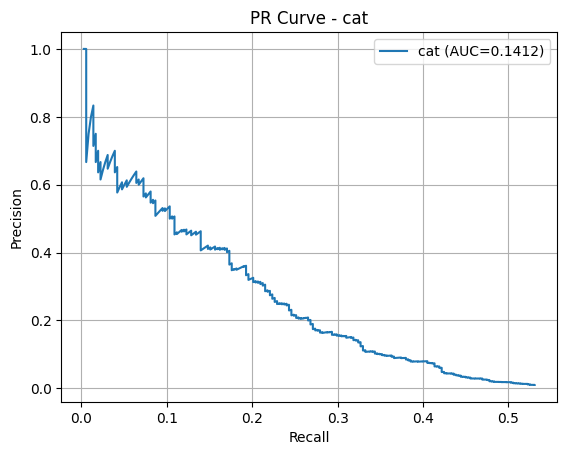

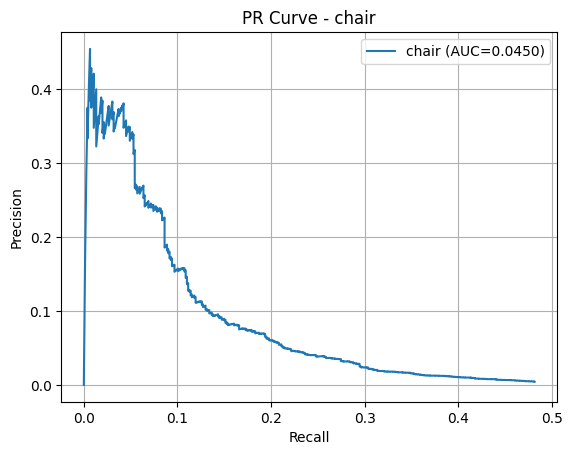

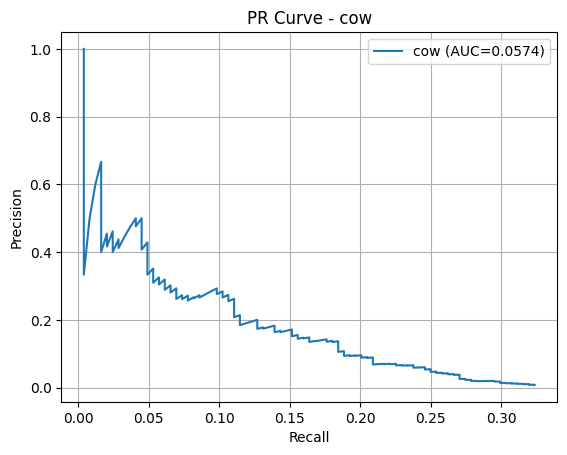

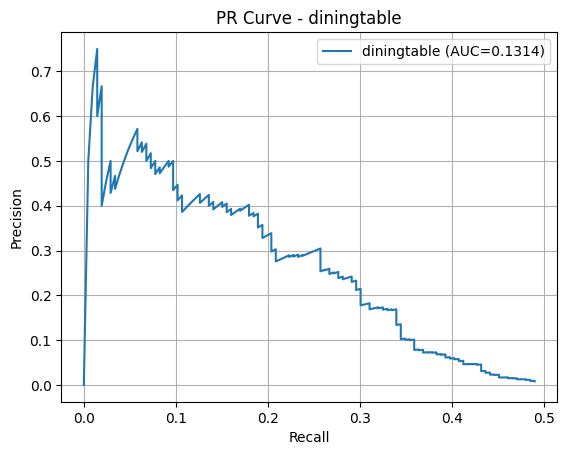

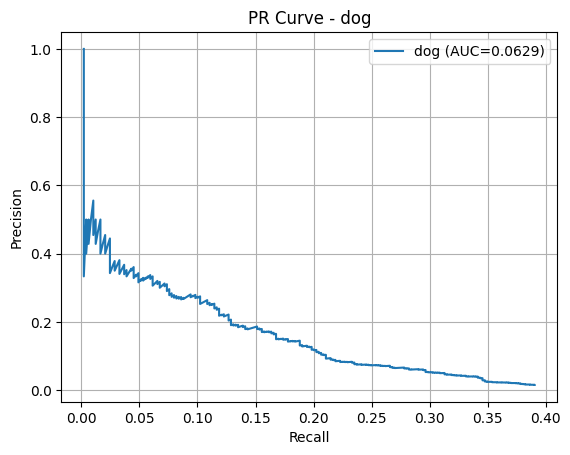

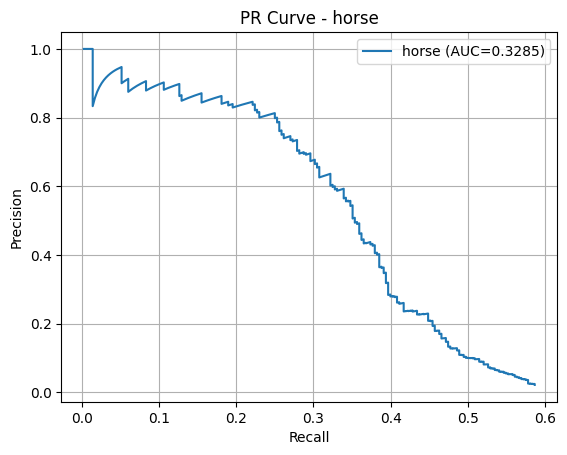

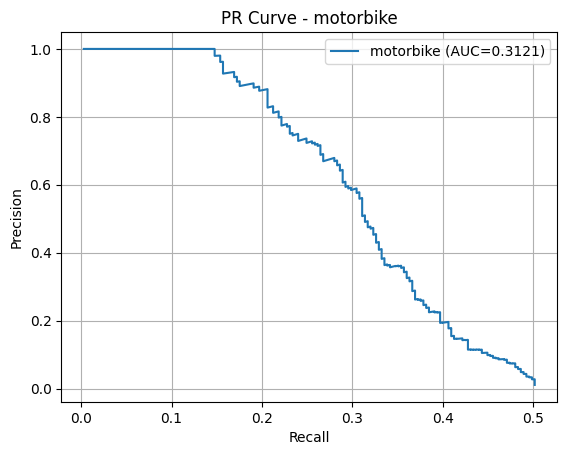

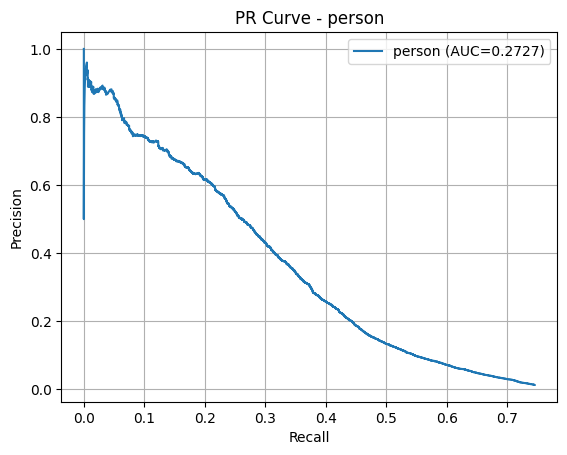

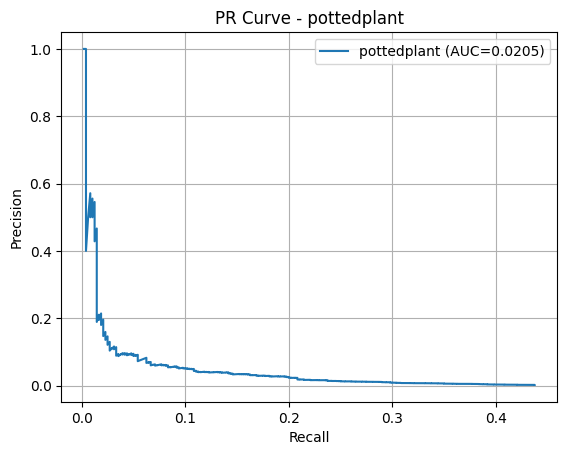

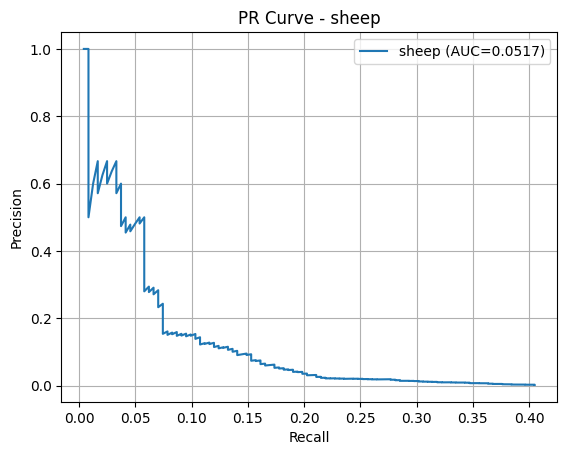

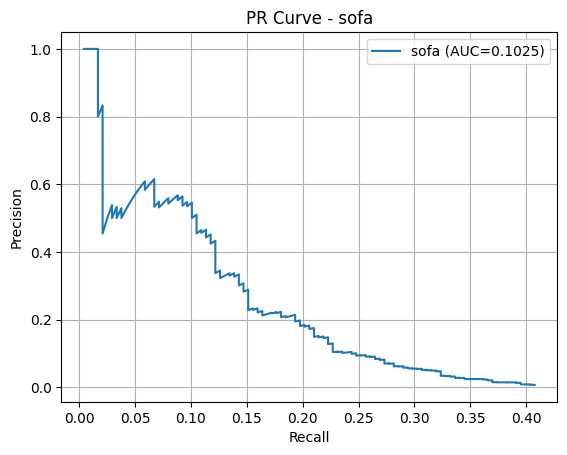

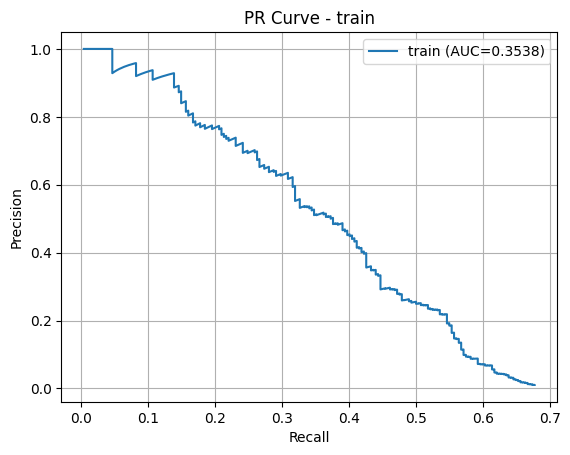

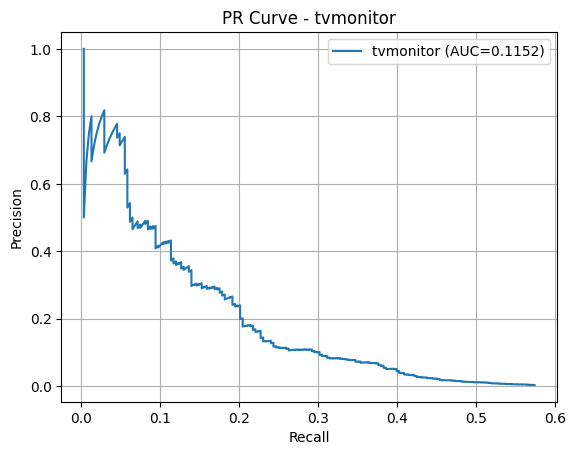

In [12]:
from collections import defaultdict
import sys
import torch
import numpy as np
from tqdm import tqdm
from collections import defaultdict

from src.predict import *

from src.eval_voc import voc_ap

from src.config import VOC_CLASSES
def voc_eval_pr(
    preds, target, VOC_CLASSES=VOC_CLASSES, threshold=0.5, use_07_metric=False
):
    """
    preds {'cat':[[image_id,confidence,x1,y1,x2,y2],...],'dog':[[],...]}
    target {(image_id,class):[[],]}
    """
    aps = []
    pr_curves = {} ## add
    
    for i, class_ in enumerate(VOC_CLASSES):
        pred = preds[class_]  # [[image_id,confidence,x1,y1,x2,y2],...]
        if len(pred) == 0:  ## No predictions made for this class
            ap = 0.0
            print(
                "---class {} ap {}--- (no predictions for this class)".format(
                    class_, ap
                )
            )
            aps += [ap]
            pr_curves[class_] = (np.array([0.0]), np.array([0.0])) ## add
            continue
        
        image_ids = [x[0] for x in pred]
        confidence = np.array([float(x[1]) for x in pred])
        BB = np.array([x[2:] for x in pred])
        # sort by confidence
        sorted_ind = np.argsort(-confidence)
        sorted_scores = np.sort(-confidence)
        BB = BB[sorted_ind, :]
        image_ids = [image_ids[x] for x in sorted_ind]

        # go down dets and mark TPs and FPs
        npos = 0.0
        for (key1, key2) in target:
            if key2 == class_:
                npos += len(target[(key1, key2)])
        nd = len(image_ids)
        tp = np.zeros(nd)
        fp = np.zeros(nd)
        for d, image_id in enumerate(image_ids):
            bb = BB[d]
            if (image_id, class_) in target:
                BBGT = target[(image_id, class_)]
                for bbgt in BBGT:
                    # compute overlaps
                    # intersection
                    ixmin = np.maximum(bbgt[0], bb[0])
                    iymin = np.maximum(bbgt[1], bb[1])
                    ixmax = np.minimum(bbgt[2], bb[2])
                    iymax = np.minimum(bbgt[3], bb[3])
                    iw = np.maximum(ixmax - ixmin + 1.0, 0.0)
                    ih = np.maximum(iymax - iymin + 1.0, 0.0)
                    inters = iw * ih

                    union = (
                        (bb[2] - bb[0] + 1.0) * (bb[3] - bb[1] + 1.0)
                        + (bbgt[2] - bbgt[0] + 1.0) * (bbgt[3] - bbgt[1] + 1.0)
                        - inters
                    )
                    if union == 0:
                        print(bb, bbgt)

                    overlaps = inters / union
                    if overlaps > threshold:
                        tp[d] = 1
                        BBGT.remove(bbgt)  # bbox has already been used
                        if len(BBGT) == 0:
                            del target[
                                (image_id, class_)
                            ]  # delete things that don't have bbox
                        break
                fp[d] = 1 - tp[d]
            else:
                fp[d] = 1
        fp = np.cumsum(fp)
        tp = np.cumsum(tp)
        rec = tp / float(npos)
        prec = tp / np.maximum(tp + fp, np.finfo(np.float64).eps)
        ap = voc_ap(rec, prec, use_07_metric)
        print("---class {} ap {}---".format(class_, ap))
        aps += [ap]
        
        pr_curves[class_] = (rec, prec)
    print("---map {}---".format(np.mean(aps)))
    return aps, pr_curves

def evaluate(model, test_dataset_file, img_root, test_loader=None):
    targets = defaultdict(list)
    preds = defaultdict(list)
    image_list = []  # image path list

    f = open(test_dataset_file)
    lines = f.readlines()
    file_list = []
    for line in lines:
        splited = line.strip().split()
        file_list.append(splited)
    f.close()

    # Collect target predictions for test set
    for index, image_file in enumerate(file_list):
        image_id = image_file[0]

        image_list.append(image_id)
        num_obj = (len(image_file) - 1) // 5
        for i in range(num_obj):
            x1 = int(image_file[1 + 5 * i])
            y1 = int(image_file[2 + 5 * i])
            x2 = int(image_file[3 + 5 * i])
            y2 = int(image_file[4 + 5 * i])
            c = int(image_file[5 + 5 * i])
            class_name = VOC_CLASSES[c]
            targets[(image_id, class_name)].append([x1, y1, x2, y2])

    print("---Evaluate model on test samples---")
    sys.stdout.flush()
    model.eval()
    for image_path in tqdm(image_list):
        result = predict_image(model, image_path, root_img_directory=img_root)
        for (
            (x1, y1),
            (x2, y2),
            class_name,
            image_id,
            prob,
        ) in result:  # image_id is actually image_path
            preds[class_name].append([image_id, prob, x1, y1, x2, y2])

    aps, pr_curves  = voc_eval_pr(preds, targets, VOC_CLASSES=VOC_CLASSES)
    return aps, pr_curves

from sklearn.metrics import auc
import matplotlib.pyplot as plt

net_loaded =  resnet50().to(device)
net_loaded.load_state_dict(torch.load('checkpoints/best_detector.pth'))
aps, pr_curves = evaluate(net_loaded, test_dataset_file=annotation_file_test, img_root=file_root_test)

for cls, (rec, prec) in pr_curves.items():
    pr_auc = auc(rec, prec)
    
    plt.figure()
    plt.plot(rec, prec, label=f"{cls} (AUC={pr_auc:.4f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"PR Curve - {cls}")
    plt.grid()
    plt.legend()
    plt.show()